# 03 - Pose Estimation

Ejemplos para modelos de pose. Los keypoints quedan como listas `[[x, y, score], ...]` dentro del `DataFrame` y se pueden plotear directamente sobre la imagen.


In [ ]:
from pathlib import Path
import sys
import os

IMAGE = "input/brooke-cagle-Ss3wTFJPAVY-unsplash.jpg"

import pandas as pd
from vision.yolo.infer import predict_image
from vision.yolo.plotting import plot_pose_keypoints, plot_image_detections

MODEL = "yolo11n-pose.pt"

print(f"Using model: {MODEL}")


Using model: yolo11n-pose.pt


In [4]:
df = predict_image(MODEL, IMAGE, confidence=0.25, task="pose")
print(
    df[
        [
            "frame",
            "class_name",
            "confidence",
            "xmin",
            "ymin",
            "xmax",
            "ymax",
            "keypoints",
        ]
    ].head()
)


   frame class_name  confidence         xmin         ymin         xmax  \
0      0     person    0.928895  1305.186157  2280.165771  2915.172607   

          ymax                                          keypoints  
0  4810.029297  [[1854.878173828125, 2525.88330078125, 0.99596...  


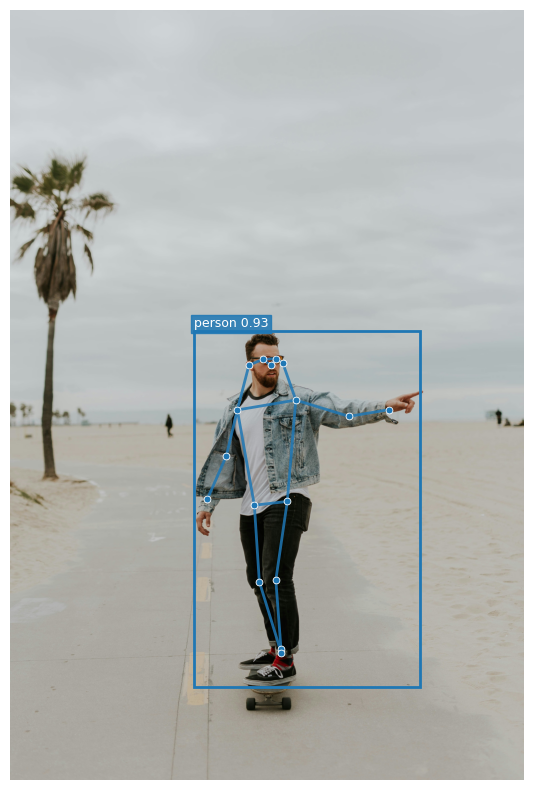

In [5]:
# Plot directo de skeleton + cajas

saved_image_name = "03_pose_detections.png"

plot_pose_keypoints(
    IMAGE,
    df,
    keypoint_threshold=0.25,
    save_to=f"outputs/{saved_image_name}",
)


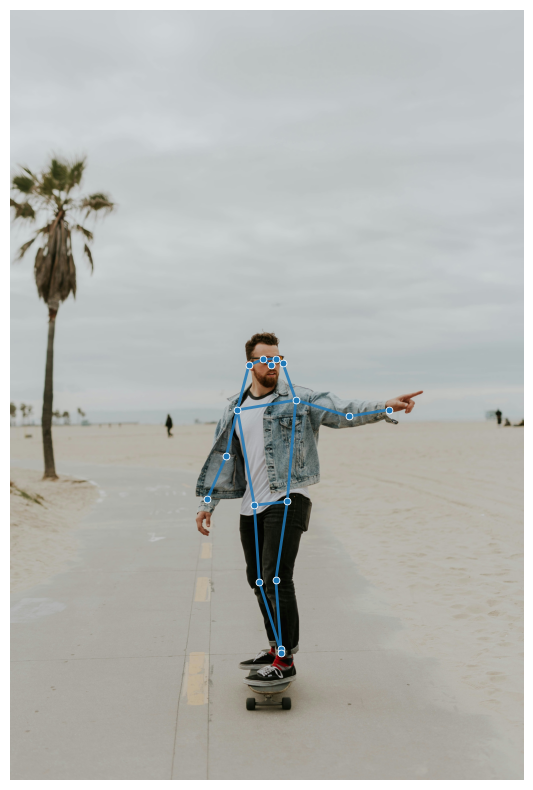

In [6]:
# Solo keypoints, sin cajas ni labels
plot_pose_keypoints(
    IMAGE,
    df,
    draw_boxes=False,
    draw_labels=False,
    keypoint_threshold=0.35,
    save_to=f"outputs/{saved_image_name}",
)


In [ ]:
# Convertir keypoints a formato largo para analisis tabular
rows = []
for det_idx, row in df.iterrows():
    keypoints = row.get("keypoints")
    if not isinstance(keypoints, list):
        continue
    for kp_idx, kp in enumerate(keypoints):
        if len(kp) >= 3:
            x, y, score = kp[:3]
        else:
            x, y = kp[:2]
            score = 1.0
        rows.append(
            {
                "detection": det_idx,
                "class_name": row["class_name"],
                "keypoint": kp_idx,
                "x": x,
                "y": y,
                "score": score,
            }
        )
keypoints_long = pd.DataFrame(rows)
print(keypoints_long.head())


   detection class_name  keypoint            x            y     score
0          0     person         0  1854.878174  2525.883301  0.995960
1          0     person         1  1892.689209  2476.963867  0.967686
2          0     person         2  1797.125122  2482.669922  0.989598
3          0     person         3  1938.081909  2507.375977  0.642153
4          0     person         4  1697.923462  2524.128906  0.923084


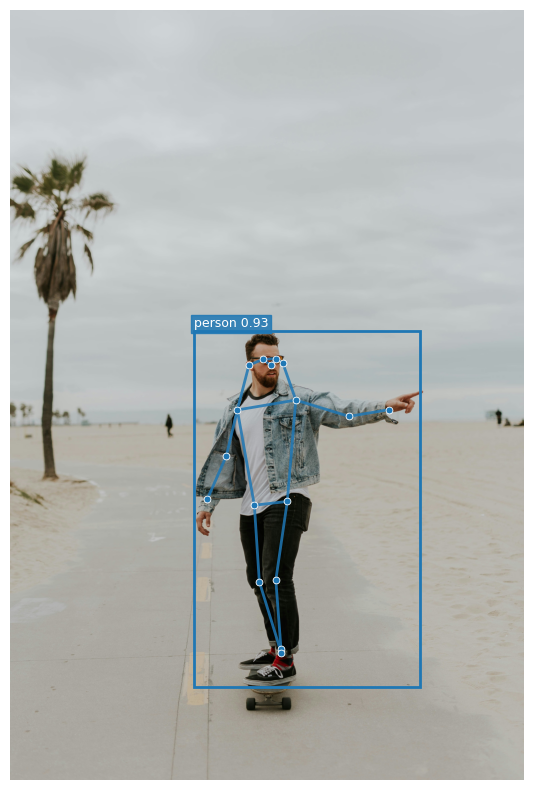

In [ ]:
# Ejemplo: quedarte con keypoints confiables y replotear solo detecciones de alta confianza
high_conf = df[df["confidence"].ge(0.5)]

plot_image_detections(
    IMAGE,
    high_conf,
    draw_boxes=True,
    draw_polygons=False,
    draw_keypoints=True,
    keypoint_threshold=0.5,
    save_to=f"outputs/{saved_image_name}",
)
